# Emilio León
## Ejercicio de Kmeans con datos de la felicidad mundial.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import KMeans
import os
os.environ["OMP_NUM_THREADS"] = '1'

In [3]:
df = pd.read_csv("hapinnessData-2019-1.csv")
df.head()

,Country,Region,Rank 2019,Score 2019,GDP 2019,Family 2019,Life Expectancy 2019,Freedom 2019,Trust 2019,Generosity 2019
0,Afghanistan,Southern Asia,154,3.203,0.350,0.517,0.361,0.000,0.025,0.158
1,Albania,Central and Eastern Europe,107,4.719,0.947,0.848,0.874,0.383,0.027,0.178
2,Algeria,Middle East and Northern Africa,88,5.211,1.002,1.160,0.785,0.086,0.114,0.073
3,Argentina,Latin America and Caribbean,47,6.086,1.092,1.432,0.881,0.471,0.050,0.066
4,Armenia,Central and Eastern Europe,116,4.559,0.850,1.055,0.815,0.283,0.064,0.095


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 156 entries, 0 to 155
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Country               156 non-null    object 
 1   Region                156 non-null    object 
 2   Rank 2019             156 non-null    int64  
 3   Score 2019            156 non-null    float64
 4   GDP 2019              156 non-null    float64
 5   Family 2019           156 non-null    float64
 6   Life Expectancy 2019  156 non-null    float64
 7   Freedom 2019          156 non-null    float64
 8   Trust 2019            156 non-null    float64
 9   Generosity 2019       156 non-null    float64
dtypes: float64(7), int64(1), object(2)
memory usage: 12.3+ KB


In [5]:
df.describe()

,Rank 2019,Score 2019,GDP 2019,Family 2019,Life Expectancy 2019,Freedom 2019,Trust 2019,Generosity 2019
count,156.000000,156.000000,156.000000,156.000000,156.000000,156.000000,156.000000,156.000000
mean,78.500000,5.407096,0.905147,1.208814,0.725244,0.392571,0.110603,0.184846
std,45.177428,1.113120,0.398389,0.299191,0.242124,0.143289,0.094538,0.095254
min,1.000000,2.853000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,39.750000,4.544500,0.602750,1.055750,0.547750,0.308000,0.047000,0.108750
50%,78.500000,5.379500,0.960000,1.271500,0.789000,0.417000,0.085500,0.177500
75%,117.250000,6.184500,1.232500,1.452500,0.881750,0.507250,0.141250,0.248250
max,156.000000,7.769000,1.684000,1.624000,1.141000,0.631000,0.453000,0.566000


In [6]:
df["Region"].value_counts()

Region
Sub-Saharan Africa                 41
Central and Eastern Europe         30
Western Europe                     20
Latin America and Caribbean        20
Middle East and Northern Africa    19
Southern Asia                      10
Eastern Asia                        6
Southeastern Asia                   6
Australia and New Zealand           2
North America                       2
Name: count, dtype: int64

In [7]:
df.isna().sum()

Country                 0
Region                  0
Rank 2019               0
Score 2019              0
GDP 2019                0
Family 2019             0
Life Expectancy 2019    0
Freedom 2019            0
Trust 2019              0
Generosity 2019         0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

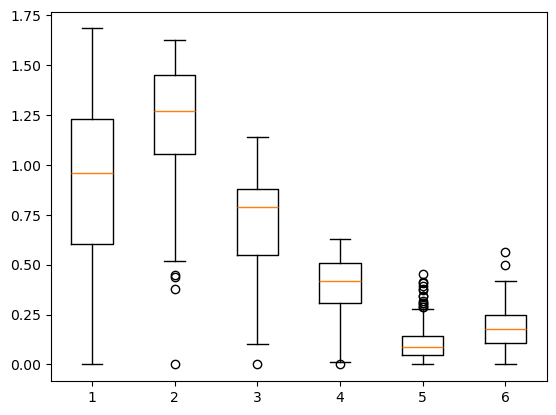

In [9]:
plt.boxplot(df[["GDP 2019", "Family 2019", "Life Expectancy 2019", "Freedom 2019", "Trust 2019", "Generosity 2019"]])
plt.show()

In [10]:
# Hay algunos datos atípicos pero probablemente con la normalización se arreglen.

In [11]:
# no hay datos duplicados ni vacíos
# La región y el país son datos categóricos que no añaden nada a nuestro análisis
# Y el Rank añadirá un sesgo, pues es el lugar de felicidad, por lo que también la excluimos.
# También excluimos score, pues es el resultado de todos los factores.

In [12]:
# Haremos un análisis de correlaciones para saber si hay otras columnas para eliminar.
df[["GDP 2019", "Family 2019", "Life Expectancy 2019", "Freedom 2019", "Trust 2019", "Generosity 2019"]].corr()

,GDP 2019,Family 2019,Life Expectancy 2019,Freedom 2019,Trust 2019,Generosity 2019
GDP 2019,1.000000,0.754906,0.835462,0.379079,0.298920,-0.079662
Family 2019,0.754906,1.000000,0.719009,0.447333,0.181899,-0.048126
Life Expectancy 2019,0.835462,0.719009,1.000000,0.390395,0.295283,-0.029511
Freedom 2019,0.379079,0.447333,0.390395,1.000000,0.438843,0.269742
Trust 2019,0.298920,0.181899,0.295283,0.438843,1.000000,0.326538
Generosity 2019,-0.079662,-0.048126,-0.029511,0.269742,0.326538,1.000000


In [13]:
# Hay columnas que muestran correlaciones fuertes, pero creo que no se deberían eliminar, pues ayudarán a ubicar mejor el agrupamiento.
# Ahora normalicemos los datos

In [14]:
from sklearn.preprocessing import StandardScaler
X = df[["GDP 2019", "Family 2019", "Life Expectancy 2019", "Freedom 2019", "Trust 2019", "Generosity 2019"]]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

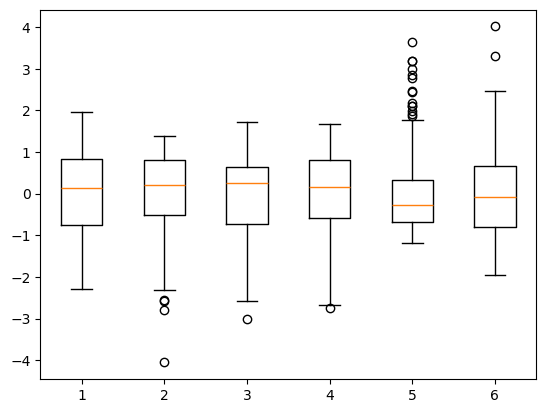

In [15]:
plt.boxplot(X_scaled)
plt.show()

In [16]:
# Sigue habiendo datos atípicos

C:\Users\ealeo\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\ealeo\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\ealeo\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\ealeo\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

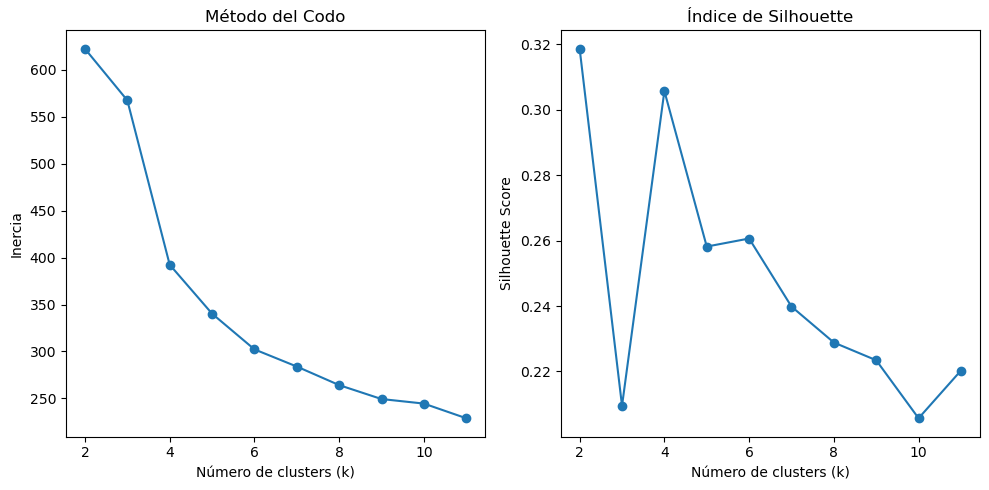

In [17]:
from sklearn.metrics import silhouette_score

inertias = []
siluetas = []

for k in range(2, 12): #12 porque tenemos 156 datos, que es aprox 12, lo que hace algo razonable para los kmeans
    km = KMeans(n_clusters=k, random_state=42, n_init = 'auto')
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    siluetas.append(silhouette_score(X_scaled, km.labels_))

# Gráfica:

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].plot(range(2,12), inertias, marker='o')
axes[0].set_title('Método del Codo')
axes[0].set_xlabel('Número de clusters (k)')
axes[0].set_ylabel('Inercia')

axes[1].plot(range(2,12), siluetas, marker='o')
axes[1].set_title('Índice de Silhouette')
axes[1].set_xlabel('Número de clusters (k)')
axes[1].set_ylabel('Silhouette Score')

plt.tight_layout()
plt.show()

In [18]:
# Con la gráfica del codo podemos decir que podemos usar 4/5 clusters.
# Pero complementando con la silueta la mejor es la de 4 clusters.

### Podemos graficar con el GDP y el life expentancy para ver como se distribuyen los datos.

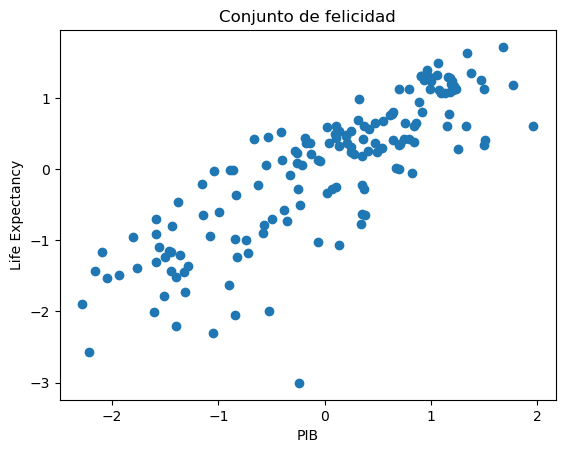

In [19]:
plt.scatter(X_scaled["GDP 2019"], X_scaled["Life Expectancy 2019"])
plt.title("Conjunto de felicidad")
plt.xlabel("PIB")
plt.ylabel("Life Expectancy")
plt.show()

In [20]:
km = KMeans(n_clusters=4, random_state=42, n_init = 'auto')
km.fit(X_scaled)

C:\Users\ealeo\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


KMeans(n_clusters=4, random_state=42)

In [21]:
# Ubicación de los centros:
km.cluster_centers_

array([[-1.00981597, -0.69449426, -1.01741243,  0.13175415, -0.03911416,
         0.53290165],
       [ 0.37606752,  0.36844276,  0.40267066, -0.06803116, -0.43863278,
        -0.5507964 ],
       [-1.52404449, -1.81832515, -1.44457567, -1.61150574, -0.28371713,
         0.27826108],
       [ 1.23376112,  0.95932021,  1.09897777,  1.08730398,  1.81007629,
         0.94812737]])

In [22]:
# y los labels:
km.labels_

array([2, 1, 1, 1, 1, 3, 3, 1, 1, 0, 1, 3, 2, 0, 1, 1, 1, 1, 1, 0, 2, 0,
       0, 3, 2, 2, 1, 1, 1, 2, 0, 0, 1, 1, 1, 1, 3, 1, 1, 1, 1, 1, 0, 3,
       1, 1, 0, 1, 3, 0, 1, 1, 0, 2, 1, 3, 1, 3, 0, 0, 0, 1, 3, 1, 1, 0,
       1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 3, 2, 0, 1, 0, 3, 2,
       1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 3, 3, 1, 2, 0, 1, 1, 3, 0, 1, 1, 1,
       1, 1, 1, 1, 3, 1, 1, 0, 1, 0, 1, 2, 3, 1, 1, 0, 1, 1, 2, 1, 1, 0,
       3, 3, 2, 1, 0, 0, 1, 2, 1, 1, 1, 1, 0, 1, 3, 3, 3, 1, 3, 1, 1, 2,
       0, 0], dtype=int32)

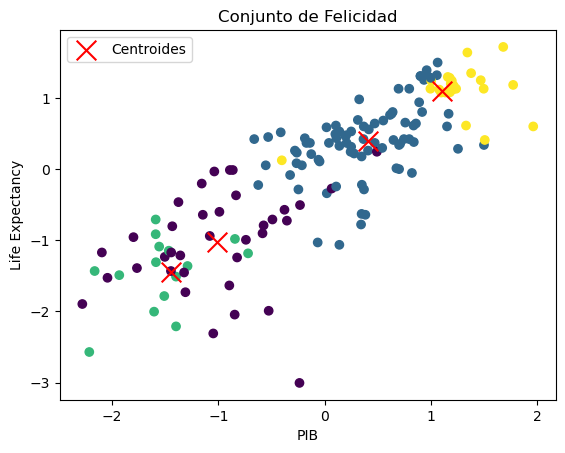

In [24]:
plt.scatter(X_scaled["GDP 2019"], X_scaled["Life Expectancy 2019"], c = km.labels_)
plt.scatter(km.cluster_centers_[:,2], km.cluster_centers_[:,2], c = "red", marker = "x", s = 200, label = "Centroides")
plt.legend()
plt.title("Conjunto de Felicidad")
plt.xlabel("PIB")
plt.ylabel("Life Expectancy")
plt.show()

In [25]:
km.cluster_centers_

array([[-1.00981597, -0.69449426, -1.01741243,  0.13175415, -0.03911416,
         0.53290165],
       [ 0.37606752,  0.36844276,  0.40267066, -0.06803116, -0.43863278,
        -0.5507964 ],
       [-1.52404449, -1.81832515, -1.44457567, -1.61150574, -0.28371713,
         0.27826108],
       [ 1.23376112,  0.95932021,  1.09897777,  1.08730398,  1.81007629,
         0.94812737]])

### Como los datos estan normalizados los datos negativos son por debajo del promedio y los positivos por encima.
### El cluster 0 son paìses con bajo en la gran mayorìa menos en libertad y generosidad(posiblmente infelices)
### El cluster 1 son paises con indices medios-altos, pero con baja generosidad y confianza.
### El cluster 2 son los peores en todos los aspectos, probablemente los mas infelices y pobres, pero con alta generosidad.
### El cluster 3 son los paises con mejroes indices, los mas felices.